# LAVI Python walk-through

This notebook demonstrates how to use the Python port of the LAVI toolbox to calculate the rhythmicity profile of a multi-channel dataset and detect bands using ABBA.

It mirrors the original MATLAB `LAVI_walk_through.m` as closely as possible, while using a more Pythonic structure.

The original MATLAB walk-through demonstrates three possibilities for statistical inference:

1. **Option A:** use a pre-computed pink-noise look-up table.
2. **Option B:** simulate pink-noise matching the data.
3. **Option C:** run ABBA without meaningful statistical inference.

Notes for the Python version:

- MATLAB indices are 1-based; Python indices are 0-based.
- The original example data are FieldTrip-like MATLAB structures. Here we load them with `scipy.io.loadmat` and extract `data.trial`, `data.fs`, `data.time`, and `data.label`.
- For real MNE workflows, you can pass NumPy arrays directly to `prepare_lavi`, or use the package's MNE helper function `prepare_lavi_mne`.

In [4]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat, savemat

# Make the local package importable.
# This works whether the notebook is run from the package root, from examples/,
# or from a parent folder such as /mnt/data.
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd() / "lavi_python", Path("/mnt/data/lavi_python")]
PROJECT_ROOT = None
for candidate in candidates:
    if (candidate / "lavi" / "__init__.py").exists():
        PROJECT_ROOT = candidate.resolve()
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the local LAVI Python package folder.")

sys.path.insert(0, str(PROJECT_ROOT))

from lavi import (
    abba,
    compute_pink_lavi,
    get_ap_of_power,
    prepare_lavi,
)
from lavi.plotting import plot_lavi

print("Using LAVI package at:", PROJECT_ROOT)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using LAVI package at: /home/mc06/Documents/CamCAN/code/lavi/lavi_python_v1


## 1. Locate the LAVI files

In MATLAB, the original code used:

```matlab
LAVIpath = 'LAVI_folder';
addpath(LAVIpath);
```

In Python, we use `pathlib.Path`. The demo data and significance table are included under `matlab_original/` in the package archive.

In [5]:
LAVI_PATH = PROJECT_ROOT
DATA_FILE = LAVI_PATH / "data" / "data.mat"
SIGLIM_FILE = LAVI_PATH / "data" / "SIGLIM.mat"

print("Project root:", PROJECT_ROOT)
print("Data file exists:", DATA_FILE.exists())
print("SIGLIM file exists:", SIGLIM_FILE.exists())

Project root: /home/mc06/Documents/CamCAN/code/lavi/lavi_python_v1
Data file exists: True
SIGLIM file exists: True


## 2. Load raw data

The original MATLAB comments were:

> Data should contain a matrix with `N_chan x N_timepoints` preprocessed data, and the sampling frequency in Hz. The script can be tested with the provided 5 minutes rest session of 3 channel EEG.

The original data were saved in a FieldTrip-like format where the data matrix is under `data.trial`.

In [6]:
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_FILE}. Check that you are running the notebook from the package folder."
    )

mat = loadmat(DATA_FILE, squeeze_me=True, struct_as_record=False)
data = mat["data"]

# FieldTrip-like structure: channels x time points.
dat_all = np.asarray(data.trial, dtype=float)
fsample = float(data.fs)
labels = list(data.label) if hasattr(data, "label") else [f"Channel {i + 1}" for i in range(dat_all.shape[0])]
time = np.asarray(data.time, dtype=float)

print("Data shape, channels x time points:", dat_all.shape)
print("Sampling frequency:", fsample)
print("Labels:", labels)
print("Duration, seconds:", time[-1] - time[0])

Data shape, channels x time points: (3, 300001)
Sampling frequency: 1000.0
Labels: ['O2', 'C2', 'F2']
Duration, seconds: 300.0


## 3. Define analysis parameters

These match the MATLAB walk-through:

```matlab
foi         = 10.^(0.5:0.025:1.65);
fsample     = data.fs;
lag         = 1.5;
width       = 5;
pink_reps   = 20;
durs        = 60;
maxIterate  = 1000;
choi        = 1:size(data.trial,1);
```

For convenience, this notebook uses all channels by default. To select channels in Python, use 0-based indices, for example `choi = [0, 1, 2]`.

In [7]:
foi = 10 ** np.arange(0.5, 1.65 + 1e-12, 0.025)
lag = 1.5          # lag between signal and copy, in cycles; default = 1.5
width = 5          # wavelet width, in cycles; default = 5
pink_reps = 20     # number of pink-noise simulations per channel; default = 20
durs = 300          # duration in seconds of each simulation; default in MATLAB was original duration
max_iterate = 1000 # maximal number of iterations in the pink simulation loop

# Python channel indices are 0-based.
choi = np.arange(dat_all.shape[0])
dat = dat_all[choi, :]
labels = [labels[i] for i in choi]

if np.isnan(dat).any():
    print("Warning: data contains NaNs. TFR will be calculated by time-domain convolution.")

print("Selected data shape:", dat.shape)
print("Number of frequencies:", len(foi))

Selected data shape: (3, 300001)
Number of frequencies: 47


## 4. Calculate LAVI of the data

The original MATLAB walk-through states:

> The actual calculation of LAVI is done with the function `Prepare_LAVI`. It assumes two inputs: `cfg` and the data. Data has to be a matrix of size `channel x timepoints`. The first output is the rhythmicity measure LAVI, as `N_channels x N_frequencies`. The second output, `cfg`, can be used to monitor which default values were assigned by the function.

In Python, `cfg` is a dictionary.

In [8]:
cfg = {
    "foi": foi,
    "fs": fsample,
    "lag": lag,
    "width": width,
    "verbose": True,
}

LAVI, cfg_out = prepare_lavi(cfg, dat) # if validate is True, it will save the outputs to a .mat file for comparison with MATLAB outputs

print("LAVI shape:", LAVI.shape)
print("First few frequencies:", cfg_out["foi"][:5])

Running LAVI frequency 1/47 (3.16 Hz)
Running LAVI frequency 2/47 (3.35 Hz)
Running LAVI frequency 3/47 (3.55 Hz)
Running LAVI frequency 4/47 (3.76 Hz)
Running LAVI frequency 5/47 (3.98 Hz)
Running LAVI frequency 6/47 (4.22 Hz)
Running LAVI frequency 7/47 (4.47 Hz)
Running LAVI frequency 8/47 (4.73 Hz)
Running LAVI frequency 9/47 (5.01 Hz)
Running LAVI frequency 10/47 (5.31 Hz)
Running LAVI frequency 11/47 (5.62 Hz)
Running LAVI frequency 12/47 (5.96 Hz)
Running LAVI frequency 13/47 (6.31 Hz)
Running LAVI frequency 14/47 (6.68 Hz)
Running LAVI frequency 15/47 (7.08 Hz)
Running LAVI frequency 16/47 (7.5 Hz)
Running LAVI frequency 17/47 (7.94 Hz)
Running LAVI frequency 18/47 (8.41 Hz)
Running LAVI frequency 19/47 (8.91 Hz)
Running LAVI frequency 20/47 (9.44 Hz)
Running LAVI frequency 21/47 (10 Hz)
Running LAVI frequency 22/47 (10.6 Hz)
Running LAVI frequency 23/47 (11.2 Hz)
Running LAVI frequency 24/47 (11.9 Hz)
Running LAVI frequency 25/47 (12.6 Hz)
Running LAVI frequency 26/47 (13.3 Hz

## 5. Plot LAVI

This corresponds to the MATLAB section:

```matlab
plot(foi, LAVI);
set(gca,'xscale','log','xtick',[2:2:10,20:10:foi(end)]);
legend(data.label)
```

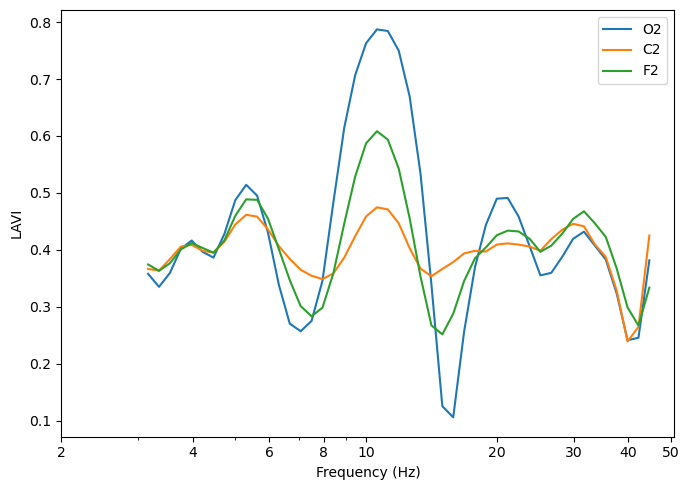

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
for ch in range(LAVI.shape[0]):
    ax.plot(foi, LAVI[ch], label=labels[ch])
ax.set_xscale("log")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("LAVI")
ax.set_xticks(list(range(2, 12, 2)) + list(range(20, int(np.ceil(foi[-1])) + 10, 10)))
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.legend()
fig.tight_layout()
plt.show()

## 6. Detect borders using ABBA

The original MATLAB comments describe the inputs to `ABBA`:

1. `LAVI`: as calculated above by `Prepare_LAVI`.
2. `foi`: frequencies of interest, same as used for calculating LAVI.
3. `alpha_range`: the frequency range in which alpha is expected. The band of a peak in this range is assigned index 0; lower-frequency bands get negative indices; higher-frequency bands get positive indices. Default: `[6 14]`.
4. `sig_lim`: significance levels per frequency. There are three alternatives:
   - **Option A:** use a table based on pre-calculated pink-noise simulations.
   - **Option B:** simulate pink-noise matching the data's power spectrum.
   - **Option C:** leave empty. Bands are found, but without meaningful statistical inference.
5. `perFreq`: whether the significance level is applied per frequency (`True`) or as the minimum/maximum over frequencies (`False`, MATLAB default).

ABBA outputs:

- `borders`: one entry per channel, with one row per band.
- `col_names`: the names of the columns in each borders matrix.
- `sigVect`: one vector per channel indicating statistical inference per frequency.

The border columns are:

1. `BegI`: index of band beginning
2. `EndI`: index of band ending
3. `PeakI`: index of band peak/trough
4. `BegF`: frequency of band beginning
5. `EndF`: frequency of band ending
6. `PeakF`: frequency of band peak/trough
7. `PeakLAVI`: LAVI value at the peak/trough
8. `PeakRel`: difference between PeakLAVI and the median
9. `Dir`: direction of the band; `1` = peak/sustained band, `-1` = trough/transient band
10. `Rel_alpha`: band identity; alpha = 0, lower bands negative, higher bands positive
11. `Sig`: significance relative to pink-noise simulations

Important Python note: index columns (`BegI`, `EndI`, `PeakI`) are **0-based** in this port.

## 7. Option A: use a pre-computed significance table

The original MATLAB walk-through notes:

> The look-up table is saved under the variable name `SIGLIM`, which has 5 dimensions: duration, sampling rate, aperiodic slope, frequency, and min/max. The input to ABBA is an `Nfreq x 2` matrix, corresponding to the last two dimensions relevant to the session/channel.

This option is much faster than simulating pink noise each time.

In [10]:
import pandas as pd
from IPython.display import display, Markdown

alpha_range = (6, 14)

if not SIGLIM_FILE.exists():
    print("SIGLIM.mat was not found. Skipping Option A.")
    borders = col_names = sigVect = None
else:
    sigmat = loadmat(SIGLIM_FILE, squeeze_me=True, struct_as_record=False)
    SIGLIM = sigmat["SIGLIM"]
    pmtrSIG = sigmat["pmtrSIG"]

    siglim = np.zeros((dat.shape[0], SIGLIM.shape[3], 2))
    dur = float(time[-1] - time[0])

    ind1 = int(np.argmin(np.abs(np.asarray(pmtrSIG.DUR) - dur)))
    ind2 = int(np.argmin(np.abs(np.asarray(pmtrSIG.FS) - fsample)))

    for ch in range(dat.shape[0]):
        _, b = get_ap_of_power(dat[ch], fsample, flim=(foi[0], foi[-1]))
        ind3 = int(np.argmin(np.abs(np.asarray(pmtrSIG.B) - b)))
        siglim[ch] = np.squeeze(SIGLIM[ind1, ind2, ind3, :, :])

    borders, col_names, sigVect = abba(
        LAVI,
        foi,
        alpha_range=alpha_range,
        siglim=siglim,
        per_freq=False,
    )

    borders_df = pd.DataFrame(borders[0], columns=col_names)
    display(Markdown(f"### ABBA Borders for Channel {labels[0]}"))
    display(borders_df)


### ABBA Borders for Channel O2

,BegI,EndI,PeakI,BegF,EndF,PeakF,PeakLAVI,PeakRel,Dir,Rel_alpha,Sig
0,0.0,3.0,1.0,3.2,3.8,3.3,0.335106,-0.066839,-1.0,-5.0,1.0
1,4.0,4.0,4.0,4.0,4.0,4.0,0.416482,0.014538,1.0,-4.0,1.0
2,5.0,6.0,6.0,4.2,4.5,4.5,0.386465,-0.015479,-1.0,-3.0,1.0
3,7.0,11.0,9.0,4.7,6.0,5.3,0.514247,0.112303,1.0,-2.0,1.0
4,12.0,16.0,14.0,6.3,7.9,7.1,0.257222,-0.144723,-1.0,-1.0,1.0
5,17.0,25.0,21.0,8.4,13.3,10.6,0.787086,0.385141,1.0,0.0,1.0
6,26.0,30.0,28.0,14.1,17.8,15.8,0.106049,-0.295896,-1.0,1.0,1.0
7,31.0,35.0,33.0,18.8,23.7,21.1,0.491190,0.089245,1.0,2.0,1.0
8,36.0,38.0,36.0,25.1,28.2,25.1,0.355259,-0.046685,-1.0,3.0,1.0
9,39.0,41.0,40.0,29.9,33.5,31.6,0.431956,0.030011,1.0,4.0,1.0


## 8. Option B: generate pink noise matching the data

The original MATLAB walk-through states:

> Pink noise can be generated with the function `computePinkLAVI`.

This option can be computationally expensive. To avoid long notebook runs, the cell below is disabled by default. Set `RUN_PINK = True` to run it. For a quick test, use a small number of repetitions first, for example `pink_reps_quick = 2`.

In [11]:
RUN_PINK = True
pink_reps_quick = 20  # increase to 20 to match the MATLAB default
alpha_range = (6, 14)
#durs = 300          # duration in seconds of each simulation; default in MATLAB was original duration
print(durs)
print(dat.shape)

if RUN_PINK:
    cfg_pink = {
        "Pink_reps": pink_reps_quick,
        "durs": durs,
        "foi": foi,
        "fs": fsample,
        "lag": lag,
        "width": width,
        "maxIterate": max_iterate,
        "verbose": True,
    }

    #print(cfg_pink)

    # MATLAB dimord: rep_freq_chan
    PINK = compute_pink_lavi(cfg_pink, dat)

    # MATLAB: pink = permute(PINK,[3,2,1]); dimord: chan_freq_rep
    pink = np.transpose(PINK, (2, 1, 0))

    # MATLAB: sig_lim = cat(3,min(pink,[],3), max(pink,[],3));
    sig_lim = np.stack([np.nanmin(pink, axis=2), np.nanmax(pink, axis=2)], axis=2)

    borders2, col_names2, sigVect2 = abba(
        LAVI,
        foi,
        alpha_range=alpha_range,
        siglim=sig_lim,
        per_freq=False,
    )

    print("PINK shape, rep x freq x chan:", PINK.shape)
else:
    PINK = None
    borders2 = None
    sigVect2 = None
    print("Pink-noise simulation skipped. Set RUN_PINK = True to run Option B.")

300
(3, 300001)
Running PINK ANALYSIS, Channel 1/3 repeat 1/20 (31 iterations). So far: 1.39 seconds.
Running PINK ANALYSIS, Channel 1/3 repeat 2/20 (20 iterations). So far: 3.75 seconds.
Running PINK ANALYSIS, Channel 1/3 repeat 3/20 (27 iterations). So far: 6.39 seconds.
Running PINK ANALYSIS, Channel 1/3 repeat 4/20 (21 iterations). So far: 8.59 seconds.
Running PINK ANALYSIS, Channel 1/3 repeat 5/20 (23 iterations). So far: 11.09 seconds.
Running PINK ANALYSIS, Channel 1/3 repeat 6/20 (25 iterations). So far: 13.60 seconds.
Running PINK ANALYSIS, Channel 1/3 repeat 7/20 (23 iterations). So far: 16.10 seconds.
Running PINK ANALYSIS, Channel 1/3 repeat 8/20 (23 iterations). So far: 18.57 seconds.
Running PINK ANALYSIS, Channel 1/3 repeat 9/20 (23 iterations). So far: 20.85 seconds.
Running PINK ANALYSIS, Channel 1/3 repeat 10/20 (21 iterations). So far: 23.27 seconds.
Running PINK ANALYSIS, Channel 1/3 repeat 11/20 (21 iterations). So far: 25.46 seconds.
Running PINK ANALYSIS, Channe

## 9. Option C: no meaningful statistical inference

This corresponds to:

```matlab
[borders3,~,sigVect3] = ABBA(LAVI, foi, alpha_range);
```

This finds bands but does not provide meaningful statistical inference relative to pink-noise simulations.

In [12]:
borders3, col_names3, sigVect3 = abba(LAVI, foi, alpha_range=alpha_range)

print("Borders for first channel, Option C:")
print(borders3[0])

Borders for first channel, Option C:
[[ 0.00000000e+00  3.00000000e+00  1.00000000e+00  3.20000000e+00
   3.80000000e+00  3.30000000e+00  3.35105873e-01 -6.68387492e-02
  -1.00000000e+00 -5.00000000e+00  1.00000000e+00]
 [ 4.00000000e+00  4.00000000e+00  4.00000000e+00  4.00000000e+00
   4.00000000e+00  4.00000000e+00  4.16482475e-01  1.45378523e-02
   1.00000000e+00 -4.00000000e+00  1.00000000e+00]
 [ 5.00000000e+00  6.00000000e+00  6.00000000e+00  4.20000000e+00
   4.50000000e+00  4.50000000e+00  3.86465254e-01 -1.54793682e-02
  -1.00000000e+00 -3.00000000e+00  1.00000000e+00]
 [ 7.00000000e+00  1.10000000e+01  9.00000000e+00  4.70000000e+00
   6.00000000e+00  5.30000000e+00  5.14247420e-01  1.12302797e-01
   1.00000000e+00 -2.00000000e+00  1.00000000e+00]
 [ 1.20000000e+01  1.60000000e+01  1.40000000e+01  6.30000000e+00
   7.90000000e+00  7.10000000e+00  2.57221977e-01 -1.44722646e-01
  -1.00000000e+00 -1.00000000e+00  1.00000000e+00]
 [ 1.70000000e+01  2.50000000e+01  2.10000000e+0

## 10. Plot LAVI and ABBA output

The original MATLAB comments:

- Each channel is plotted in a separate subplot.
- Black: LAVI of original data.
- Pink/grey: LAVI of simulations, if generated.
- Green: significantly increased bands.
- Blue: significantly decreased bands.

In this notebook, the significance vector is chosen in this order:

1. use Option B (`sigVect2`) if pink simulations were run;
2. otherwise use Option A (`sigVect`) if the lookup table was available;
3. otherwise use Option C (`sigVect3`).

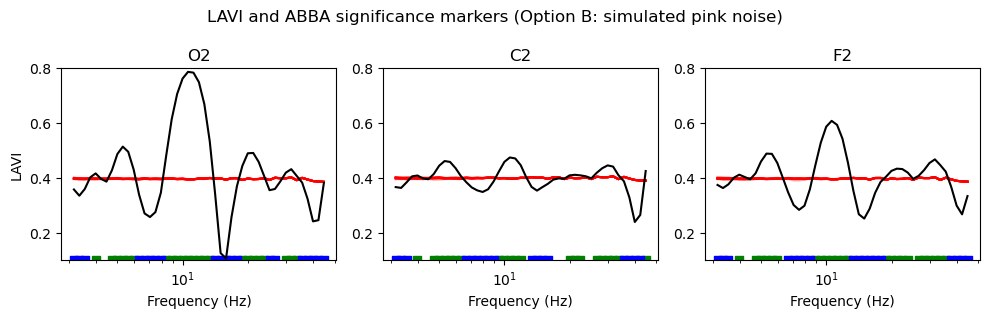

In [13]:
if 'sigVect2' in locals() and sigVect2 is not None:
    sig_to_plot = sigVect2
    title_suffix = "Option B: simulated pink noise"
elif 'sigVect' in locals() and sigVect is not None:
    sig_to_plot = sigVect
    title_suffix = "Option A: lookup table"
else:
    sig_to_plot = sigVect3
    title_suffix = "Option C: no meaningful inference"

cols = 3
rows = int(np.ceil(LAVI.shape[0] / cols))
fig, axes = plt.subplots(rows, cols, figsize=(10, 3.2 * rows), squeeze=False)
axes = axes.ravel()

for ch in range(LAVI.shape[0]):
    ax = axes[ch]

    if PINK is not None:
        # PINK has shape rep x freq x chan.
        ax.plot(foi, PINK[:, :, ch].T, alpha=0.35, color="red")

    ax.plot(foi, LAVI[ch], linewidth=1.5, color="black")

    posind = np.asarray(sig_to_plot[ch]) > 0
    negind = np.asarray(sig_to_plot[ch]) < 0

    # Colours are specified here to match the original MATLAB comments.
    ax.scatter(foi[posind], np.ones(np.sum(posind)) * 0.1, marker="s", color="green")
    ax.scatter(foi[negind], np.ones(np.sum(negind)) * 0.1, marker="s", color="blue")

    ax.set_xscale("log")
    ax.set_ylim([0.1, 0.8])
    ax.set_xlabel("Frequency (Hz)")
    if ch % cols == 0:
        ax.set_ylabel("LAVI")
    ax.set_title(labels[ch] if ch < len(labels) else f"Channel {ch + 1}")

for ax in axes[LAVI.shape[0]:]:
    ax.axis("off")

fig.suptitle(f"LAVI and ABBA significance markers ({title_suffix})")
fig.tight_layout()
plt.show()


## 11. Save Python outputs for numerical validation

A practical next step is to run the original MATLAB walk-through and save its outputs, for example:

```matlab
save('matlab_validation_outputs.mat', ...
     'LAVI', 'foi', 'borders', 'sigVect', 'borders3', 'sigVect3', ...
     '-v7.3')
```

Then save the Python outputs from this notebook:

In [14]:
SAVE_OUTPUTS = True  # Set to False to skip saving outputs.

if SAVE_OUTPUTS:
    out_file = LAVI_PATH / "data" /"python_validation_outputs.mat"
    savemat(
        out_file,
        {
            "LAVI_py": LAVI,
            "foi_py": foi,
            "sigVect_optionA_py": np.asarray(sigVect, dtype=object) if ("sigVect" in locals() and sigVect is not None) else np.array([]),
            "sigVect_optionB_py": np.asarray(sigVect2, dtype=object) if ("sigVect2" in locals() and  sigVect2 is not None) else np.array([]),
            "sigVect_optionC_py": np.asarray(sigVect3, dtype=object) if ("sigVect3" in locals() and  sigVect3 is not None) else np.array([]),
        },
    )
    print("Saved:", out_file)

    out_file = LAVI_PATH / "data" / "python_validation_abba_outputs.mat"
    savemat(
        out_file,
        {
            "borders_optionA_py": borders if ("borders" in locals() and borders is not None) else np.array([]),
            "col_names_optionA_py": col_names if ("col_names" in locals() and col_names is not None) else np.array([]),
            "borders_optionB_py": borders2 if ("borders2" in locals() and borders2 is not None) else np.array([]),
            "col_names_optionB_py": col_names2 if ("col_names2" in locals() and col_names2 is not None) else np.array([]),
            "borders_optionC_py": borders3 if ("borders3" in locals() and borders3 is not None) else np.array([]),
            "col_names_optionC_py": col_names3 if ("col_names3" in locals() and col_names3 is not None) else np.array([]),
        },
    )
    print("Saved:", out_file)

    out_file = LAVI_PATH / "data" / "python_validation_pink_outputs.mat"
    savemat(
        out_file,
        {
            "PINK_py": PINK if ("PINK" in locals() and PINK is not None) else np.array([]),
            "sig_lim_py": sig_lim if ("sig_lim" in locals() and sig_lim is not None) else np.array([]),
        },
    )
    print("Saved:", out_file)
else:
    print("Output saving skipped. Set SAVE_OUTPUTS = True to save .mat validation outputs.")

Saved: /home/mc06/Documents/CamCAN/code/lavi/lavi_python_v1/data/python_validation_outputs.mat
Saved: /home/mc06/Documents/CamCAN/code/lavi/lavi_python_v1/data/python_validation_abba_outputs.mat
Saved: /home/mc06/Documents/CamCAN/code/lavi/lavi_python_v1/data/python_validation_pink_outputs.mat


## 12. Numerical validation template

After running MATLAB and Python on the same data, compare deterministic outputs first. Start with `LAVI`, then compare ABBA band structure.

For surrogate/pink-noise outputs, exact equality is not expected unless the random number generation and IAAFT implementation are matched very carefully. For that part, compare distributions, thresholds, and final scientific interpretation.

In [16]:
import pandas as pd

# Example template. Edit MATLAB_VALIDATION_FILE after saving outputs in MATLAB.
MATLAB_VALIDATION_FILE = LAVI_PATH / "data" /"matlab_validation_outputs.mat"

if MATLAB_VALIDATION_FILE.exists():
    mat = loadmat(MATLAB_VALIDATION_FILE, squeeze_me=True, struct_as_record=False)
    LAVI_mat = np.asarray(mat["LAVI"], dtype=float)
    borders_mat = mat["borders2"]

    print("Max absolute difference (LAVI):", np.nanmax(np.abs(LAVI - LAVI_mat)))
    print("Mean absolute difference (LAVI):", np.nanmean(np.abs(LAVI - LAVI_mat)))
    print("Correlation:", np.corrcoef(LAVI.ravel(), LAVI_mat.ravel())[0, 1])

    np.testing.assert_allclose(LAVI, LAVI_mat, rtol=1e-3, atol=1e-8) # the relative tolerance is set to 1e-3 to account for small numerical differences, but it fails for smaller differences, so we use 1e-3 instead of 1e-6
    #print("LAVI passed strict allclose test.")

    print("ABBA borders shape:", len(borders2), "x", len(borders2[0]), "x", len(borders2[0][0]))
    print("ABBA borders_mat shape:", len(borders_mat), "x", len(borders_mat[0]), "x", len(borders_mat[0][0]))

    for ch in range(len(borders2)):
        print(f"Channel {ch + 1}:")
        print("Python borders:", borders2[ch].shape)
        print("MATLAB borders:", borders_mat[ch].shape)

        borders_df = pd.DataFrame(borders2[ch], columns=col_names2)
        borders_mat_df = pd.DataFrame(borders_mat[ch], columns=col_names2)

        diff_df = borders_df.subtract(borders_mat_df)

        print("Max absolute difference (BegF):", diff_df['BegF'].abs().max().max())
        print("Max absolute difference (EndF):", diff_df['EndF'].abs().max().max())
        print("Max absolute difference (PeakF):", diff_df['PeakF'].abs().max().max())
        print("Max absolute difference (PeakLAVI):", diff_df['PeakLAVI'].abs().max().max())
        print("Max absolute difference (Dir):", diff_df['Dir'].abs().max().max())
        print("Max absolute difference (Rel_alpha):", diff_df['Rel_alpha'].abs().max().max())

else:
    print("MATLAB validation file not found yet:", MATLAB_VALIDATION_FILE)

Max absolute difference (LAVI): 8.377665104530863e-06
Mean absolute difference (LAVI): 1.583327879027452e-06
Correlation: 0.9999999997543082
ABBA borders shape: 3 x 11 x 11
ABBA borders_mat shape: 3 x 11 x 11
Channel 1:
Python borders: (11, 11)
MATLAB borders: (11, 11)
Max absolute difference (BegF): 0.0
Max absolute difference (EndF): 0.0
Max absolute difference (PeakF): 0.0
Max absolute difference (PeakLAVI): 5.958552199702982e-06
Max absolute difference (Dir): 0.0
Max absolute difference (Rel_alpha): 0.0
Channel 2:
Python borders: (12, 11)
MATLAB borders: (12, 11)
Max absolute difference (BegF): 0.0
Max absolute difference (EndF): 0.0
Max absolute difference (PeakF): 0.0
Max absolute difference (PeakLAVI): 4.202312303358546e-06
Max absolute difference (Dir): 0.0
Max absolute difference (Rel_alpha): 0.0
Channel 3:
Python borders: (11, 11)
MATLAB borders: (11, 11)
Max absolute difference (BegF): 0.0
Max absolute difference (EndF): 0.0
Max absolute difference (PeakF): 0.0
Max absolute 

## 13. Using MNE data instead of FieldTrip-like MATLAB structs

The correct MNE loader depends on your original file format (`.fif`, BrainVision, EEGLAB, etc.). The package includes `prepare_lavi_mne` for MNE objects, but this notebook avoids hard-coding a loader.

Typical usage would look like:

```python
import mne
from lavi import prepare_lavi_mne

raw = mne.io.read_raw_fif("your_file_raw.fif", preload=True)
raw.pick("eeg")  # or "meg", depending on your data

lavi, cfg = prepare_lavi_mne(
    raw,
    foi=foi,
    lag=1.5,
    width=5,
)
```

If the data are already a NumPy array of shape `channels x timepoints`, simply use `prepare_lavi(cfg, data_array)` as above.